In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r'C:\Users\Computec\Desktop\lotfy\Global_Superstore2.csv', encoding='latin-1')

# EDA

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [5]:
df.shape

(51290, 24)

In [6]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [7]:
cols_to_check = [
    'City', 'State', 'Country', 'Product Name', 
    'Order Priority', 'Segment', 'Ship Mode', 
    'Region', 'Category', 'Sub-Category', 'Quantity', 'Order Date'
]

# نطبع القيم وعدد مرات ظهورها لكل عمود محدد
for col in cols_to_check:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

--- City ---
City
New York City     915
Los Angeles       747
Philadelphia      537
San Francisco     510
Santo Domingo     443
                 ... 
Vesoul              1
Várzea Grande       1
Luanshya            1
Kissimmee           1
Victoria Falls      1
Name: count, Length: 3636, dtype: int64


--- State ---
State
California            2001
England               1499
New York              1128
Texas                  985
Ile-de-France          981
                      ... 
Lambayeque               1
Aveiro                   1
Lima                     1
Medea                    1
Matabeleland North       1
Name: count, Length: 1094, dtype: int64


--- Country ---
Country
United States    9994
Australia        2837
France           2827
Mexico           2644
Germany          2065
                 ... 
Bahrain             2
South Sudan         2
Chad                2
Burundi             2
Eritrea             2
Name: count, Length: 147, dtype: int64


--- Product Name ---
Product Nam

In [8]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375915
std,14806.29199,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296804
min,1.00000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.000000
25%,12823.25000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [9]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df[['Segment','Ship Mode','City','State','Country','Region','Category',	'Sub-Category','Product Name']].nunique()

Segment            3
Ship Mode          4
City            3636
State           1094
Country          147
Region            13
Category           3
Sub-Category      17
Product Name    3788
dtype: int64

In [12]:
columns_to_group = ['City', 'State', 'Country']
for col in columns_to_group:
    value_counts = df[col].value_counts()
    to_replace = value_counts[value_counts <= 20].index
    df[col] = df[col].replace(to_replace, 'other')

df[columns_to_group].head()

,City,State,Country
0,New York City,New York,United States
1,Wollongong,New South Wales,Australia
2,Brisbane,Queensland,Australia
3,Berlin,Berlin,Germany
4,Dakar,Dakar,Senegal


In [13]:
df[['Segment','Ship Mode','City','State','Country','Region','Category',	'Sub-Category','Product Name']].nunique()

Segment            3
Ship Mode          4
City             511
State            437
Country          111
Region            13
Category           3
Sub-Category      17
Product Name    3788
dtype: int64

In [14]:
columns_to_count = ['Segment','Ship Mode','City','State','Country','Region','Category', 'Sub-Category','Product Name','Order Priority']

for col in columns_to_count:
    print(f"Value counts for column: {col}")
    print(df[col].value_counts())
    print("-" * 30)

Value counts for column: Segment
Segment
Consumer       26518
Corporate      15429
Home Office     9343
Name: count, dtype: int64
------------------------------
Value counts for column: Ship Mode
Ship Mode
Standard Class    30775
Second Class      10309
First Class        7505
Same Day           2701
Name: count, dtype: int64
------------------------------
Value counts for column: City
City
other                18809
New York City          915
Los Angeles            747
Philadelphia           537
San Francisco          510
                     ...  
San Fernando            21
Albury                  21
Bom Jesus da Lapa       21
Pekanbaru               21
Hamm                    21
Name: count, Length: 511, dtype: int64
------------------------------
Value counts for column: State
State
other          4991
California     2001
England        1499
New York       1128
Texas           985
               ... 
Borno            21
Markazi          21
Idaho            21
Cross River      21
No

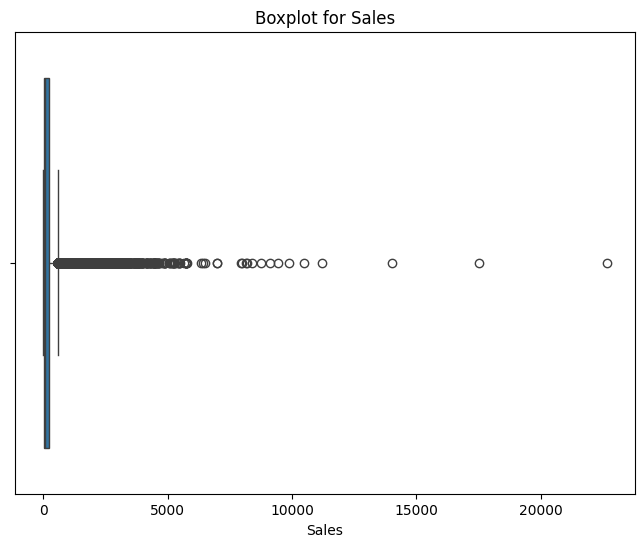

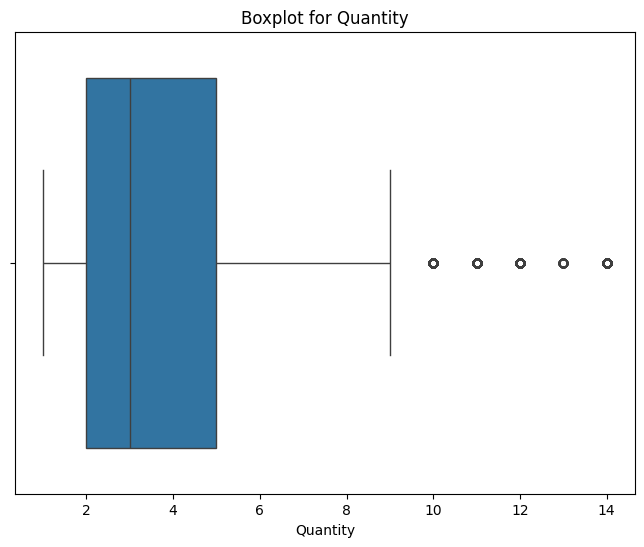

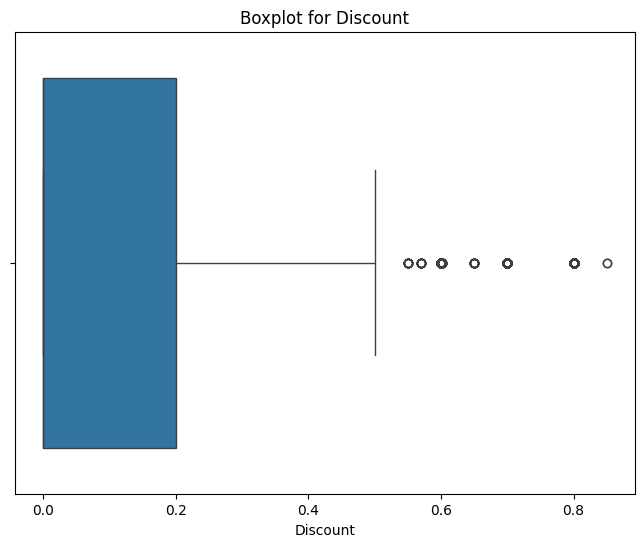

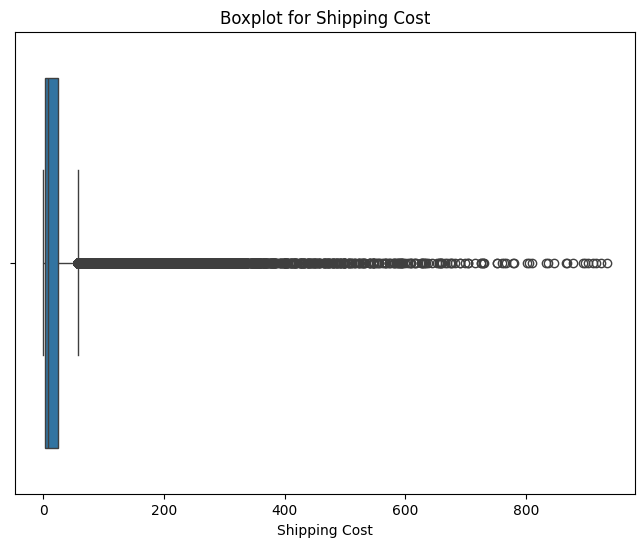

In [15]:
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Shipping Cost']

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.xlabel(col)
    plt.show()

# **Delete unnecessary columns**

In [16]:
df.drop(['Ship Date','Postal Code','Profit','Row ID','Order ID','Customer ID','Customer Name','Product ID'],axis=1,inplace=True)
#All of these values ​​will not be used by the machine during the learning process.
#postal code have many null value and not necessary beacause we have city , country and state columns and it's enough for learning.

In [17]:
df.shape

(51290, 16)

# **Data Preprocessing**

In [18]:
df['Order Date']=pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day'] = df['Order Date'].dt.day
df['day_of_week'] = df['Order Date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      51290 non-null  datetime64[ns]
 1   Ship Mode       51290 non-null  object        
 2   Segment         51290 non-null  object        
 3   City            51290 non-null  object        
 4   State           51290 non-null  object        
 5   Country         51290 non-null  object        
 6   Market          51290 non-null  object        
 7   Region          51290 non-null  object        
 8   Category        51290 non-null  object        
 9   Sub-Category    51290 non-null  object        
 10  Product Name    51290 non-null  object        
 11  Sales           51290 non-null  float64       
 12  Quantity        51290 non-null  int64         
 13  Discount        51290 non-null  float64       
 14  Shipping Cost   51290 non-null  float64       
 15  Or

In [20]:
df.isnull().sum()

Order Date        0
Ship Mode         0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Shipping Cost     0
Order Priority    0
year              0
month             0
day               0
day_of_week       0
is_weekend        0
dtype: int64

In [21]:
df.duplicated().sum()

1

<Axes: xlabel='Sales', ylabel='Count'>

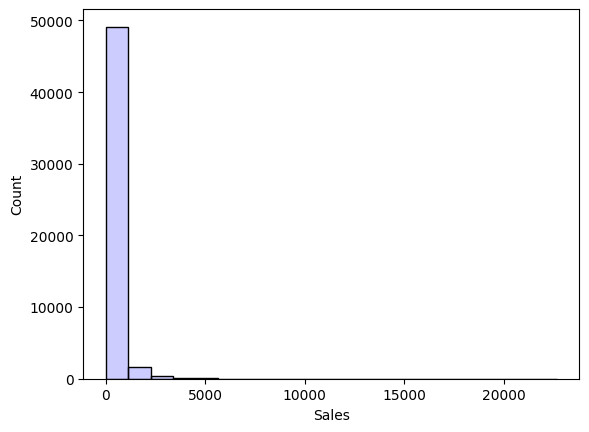

In [22]:
sns.histplot(df['Sales'],bins=20,color='blue',edgecolor='black',alpha=0.2)

In [23]:
df['Sales']=np.log1p(df['Sales'])

<Axes: xlabel='Sales', ylabel='Count'>

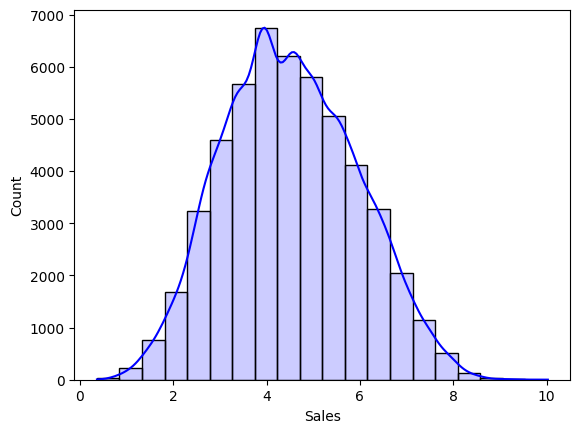

In [24]:
sns.histplot(df['Sales'],bins=20,color='blue',edgecolor='black',alpha=0.2,kde=True)

<Axes: xlabel='Shipping Cost', ylabel='Count'>

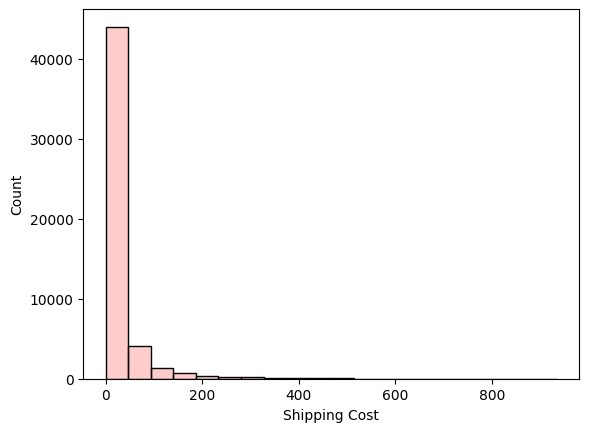

In [25]:
sns.histplot(df['Shipping Cost'],bins=20,color='red',edgecolor='black',alpha=0.2)

In [26]:
df['Shipping Cost']=np.log1p(df['Shipping Cost'])

<Axes: xlabel='Shipping Cost', ylabel='Count'>

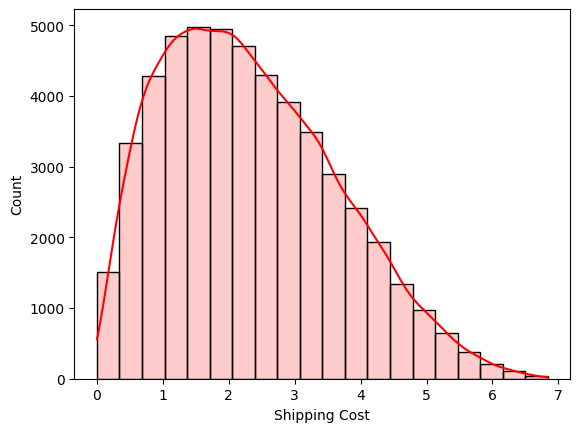

In [27]:
sns.histplot(df['Shipping Cost'],bins=20,color='red',edgecolor='black',alpha=0.2,kde=True)

<Axes: xlabel='Discount', ylabel='Count'>

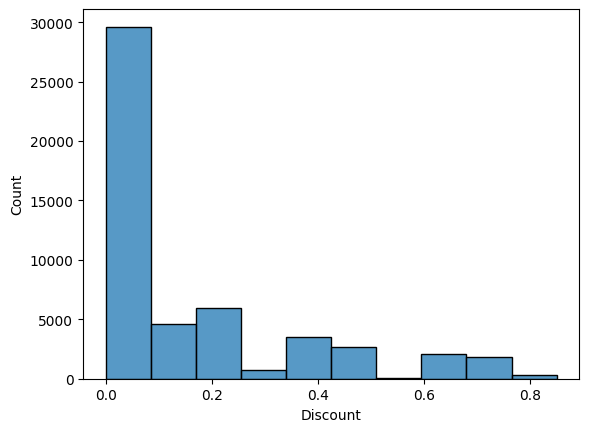

In [28]:
sns.histplot(df['Discount'],bins=10)

In [29]:
col = 'Discount'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"  Lower Bound ({col}): {lower_bound}")
print(f"  Upper Bound ({col}): {upper_bound}")

df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)



  Lower Bound (Discount): -0.30000000000000004
  Upper Bound (Discount): 0.5


<Axes: xlabel='Discount', ylabel='Count'>

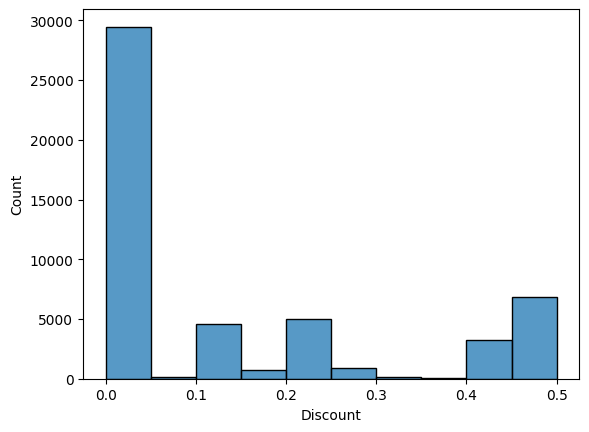

In [30]:
sns.histplot(df['Discount'],bins=10)

## Feature Engineering

**Nominal columns**

In [31]:
test_df=df
test_df

,Order Date,Ship Mode,Segment,City,State,Country,Market,Region,Category,Sub-Category,...,Sales,Quantity,Discount,Shipping Cost,Order Priority,year,month,day,day_of_week,is_weekend
0,2012-07-31,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,...,7.745284,7,0.0,6.840087,Critical,2012,7,31,1,0
1,2013-02-05,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,...,8.218894,9,0.1,6.829394,Critical,2013,2,5,1,0
2,2013-10-17,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,...,8.551821,9,0.1,6.820551,Medium,2013,10,17,3,0
3,2013-01-28,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,...,7.970226,5,0.1,6.814719,Medium,2013,1,28,0,0
4,2013-11-05,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,...,7.949430,8,0.0,6.806874,Critical,2013,11,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-06-19,Same Day,Corporate,other,other,Japan,APAC,North Asia,Office Supplies,Fasteners,...,4.191169,5,0.0,0.009950,Medium,2014,6,19,3,0
51286,2014-06-20,Standard Class,Consumer,Houston,Texas,United States,US,Central,Office Supplies,Appliances,...,0.367417,1,0.5,0.009950,Medium,2014,6,20,4,0
51287,2013-12-02,Same Day,Home Office,other,California,United States,US,West,Office Supplies,Envelopes,...,3.174715,3,0.0,0.009950,High,2013,12,2,0,0
51288,2012-02-18,Standard Class,Home Office,other,São Paulo,Brazil,LATAM,South,Office Supplies,Binders,...,2.670002,2,0.0,0.000000,Medium,2012,2,18,5,1


In [32]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ['Segment','Ship Mode','Region','Category','Sub-Category']


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_data = ohe.fit_transform(test_df[nominal_cols])
encoded_feature_names = ohe.get_feature_names_out(nominal_cols)
df_encode = pd.DataFrame(encoded_data, columns=encoded_feature_names, index=test_df.index)

In [33]:
df_encode

,Segment_Consumer,Segment_Corporate,Segment_Home Office,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Region_Africa,Region_Canada,Region_Caribbean,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51286,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51287,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51288,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
!pip install category_encoders

In [35]:
from category_encoders import BinaryEncoder

In [36]:
bin=BinaryEncoder(cols=['City','State','Country','Product Name'])
bin_encode=bin.fit_transform(test_df)
bin_encode

,Order Date,Ship Mode,Segment,City_0,City_1,City_2,City_3,City_4,City_5,City_6,...,Sales,Quantity,Discount,Shipping Cost,Order Priority,year,month,day,day_of_week,is_weekend
0,2012-07-31,Same Day,Consumer,0,0,0,0,0,0,0,...,7.745284,7,0.0,6.840087,Critical,2012,7,31,1,0
1,2013-02-05,Second Class,Corporate,0,0,0,0,0,0,0,...,8.218894,9,0.1,6.829394,Critical,2013,2,5,1,0
2,2013-10-17,First Class,Consumer,0,0,0,0,0,0,0,...,8.551821,9,0.1,6.820551,Medium,2013,10,17,3,0
3,2013-01-28,First Class,Home Office,0,0,0,0,0,0,1,...,7.970226,5,0.1,6.814719,Medium,2013,1,28,0,0
4,2013-11-05,Same Day,Consumer,0,0,0,0,0,0,1,...,7.949430,8,0.0,6.806874,Critical,2013,11,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-06-19,Same Day,Corporate,0,0,0,0,0,1,0,...,4.191169,5,0.0,0.009950,Medium,2014,6,19,3,0
51286,2014-06-20,Standard Class,Consumer,0,0,1,0,0,1,1,...,0.367417,1,0.5,0.009950,Medium,2014,6,20,4,0
51287,2013-12-02,Same Day,Home Office,0,0,0,0,0,1,0,...,3.174715,3,0.0,0.009950,High,2013,12,2,0,0
51288,2012-02-18,Standard Class,Home Office,0,0,0,0,0,1,0,...,2.670002,2,0.0,0.000000,Medium,2012,2,18,5,1


**Ordinal Columns**

In [37]:
bin_encode['lb_Order Priority']=bin_encode['Order Priority'].map({"Low":0,
                                                  "Medium":1,
                                                  "High":2,
                                                  "Critical":3
                                                 })

In [38]:
bin_encode

,Order Date,Ship Mode,Segment,City_0,City_1,City_2,City_3,City_4,City_5,City_6,...,Quantity,Discount,Shipping Cost,Order Priority,year,month,day,day_of_week,is_weekend,lb_Order Priority
0,2012-07-31,Same Day,Consumer,0,0,0,0,0,0,0,...,7,0.0,6.840087,Critical,2012,7,31,1,0,3
1,2013-02-05,Second Class,Corporate,0,0,0,0,0,0,0,...,9,0.1,6.829394,Critical,2013,2,5,1,0,3
2,2013-10-17,First Class,Consumer,0,0,0,0,0,0,0,...,9,0.1,6.820551,Medium,2013,10,17,3,0,1
3,2013-01-28,First Class,Home Office,0,0,0,0,0,0,1,...,5,0.1,6.814719,Medium,2013,1,28,0,0,1
4,2013-11-05,Same Day,Consumer,0,0,0,0,0,0,1,...,8,0.0,6.806874,Critical,2013,11,5,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-06-19,Same Day,Corporate,0,0,0,0,0,1,0,...,5,0.0,0.009950,Medium,2014,6,19,3,0,1
51286,2014-06-20,Standard Class,Consumer,0,0,1,0,0,1,1,...,1,0.5,0.009950,Medium,2014,6,20,4,0,1
51287,2013-12-02,Same Day,Home Office,0,0,0,0,0,1,0,...,3,0.0,0.009950,High,2013,12,2,0,0,2
51288,2012-02-18,Standard Class,Home Office,0,0,0,0,0,1,0,...,2,0.0,0.000000,Medium,2012,2,18,5,1,1


In [39]:
test=pd.concat([bin_encode,df_encode],axis=1)

In [40]:
test

,Order Date,Ship Mode,Segment,City_0,City_1,City_2,City_3,City_4,City_5,City_6,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2012-07-31,Same Day,Consumer,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2013-02-05,Second Class,Corporate,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2013-10-17,First Class,Consumer,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2013-01-28,First Class,Home Office,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2013-11-05,Same Day,Consumer,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,2014-06-19,Same Day,Corporate,0,0,0,0,0,1,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51286,2014-06-20,Standard Class,Consumer,0,0,1,0,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51287,2013-12-02,Same Day,Home Office,0,0,0,0,0,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51288,2012-02-18,Standard Class,Home Office,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
test.drop([ 'Ship Mode', 'Segment','Market', 'Region',
       'Category', 'Sub-Category','Order Priority'],axis=1,inplace=True)

In [42]:
test.columns

Index(['Order Date', 'City_0', 'City_1', 'City_2', 'City_3', 'City_4',
       'City_5', 'City_6', 'City_7', 'City_8', 'State_0', 'State_1', 'State_2',
       'State_3', 'State_4', 'State_5', 'State_6', 'State_7', 'State_8',
       'Country_0', 'Country_1', 'Country_2', 'Country_3', 'Country_4',
       'Country_5', 'Country_6', 'Product Name_0', 'Product Name_1',
       'Product Name_2', 'Product Name_3', 'Product Name_4', 'Product Name_5',
       'Product Name_6', 'Product Name_7', 'Product Name_8', 'Product Name_9',
       'Product Name_10', 'Product Name_11', 'Sales', 'Quantity', 'Discount',
       'Shipping Cost', 'year', 'month', 'day', 'day_of_week', 'is_weekend',
       'lb_Order Priority', 'Segment_Consumer', 'Segment_Corporate',
       'Segment_Home Office', 'Ship Mode_First Class', 'Ship Mode_Same Day',
       'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Region_Africa',
       'Region_Canada', 'Region_Caribbean', 'Region_Central',
       'Region_Central Asia', 'Regio

## Visualization

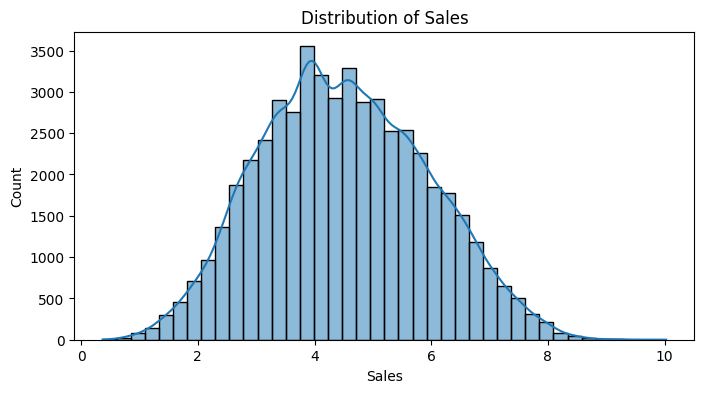

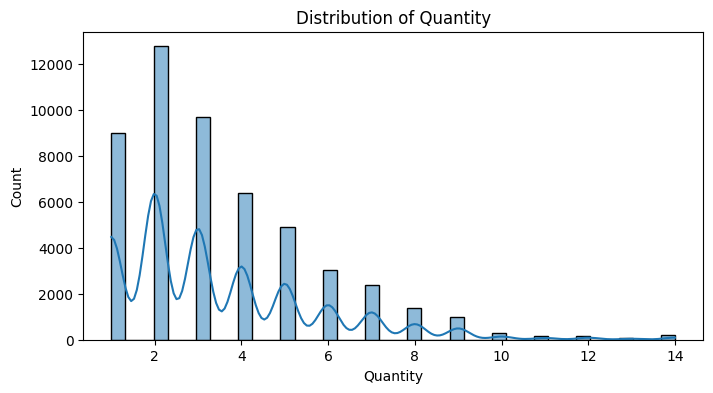

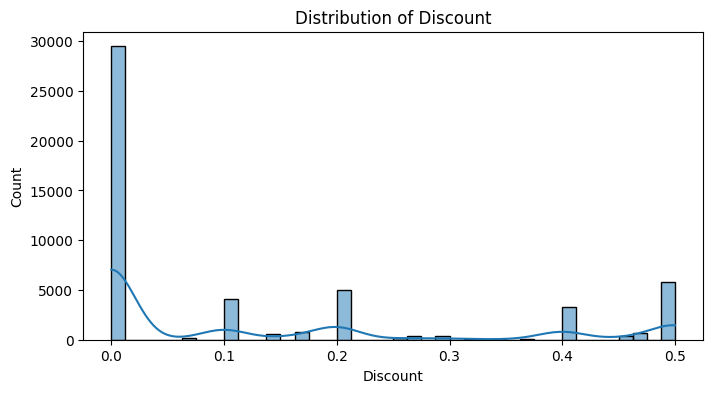

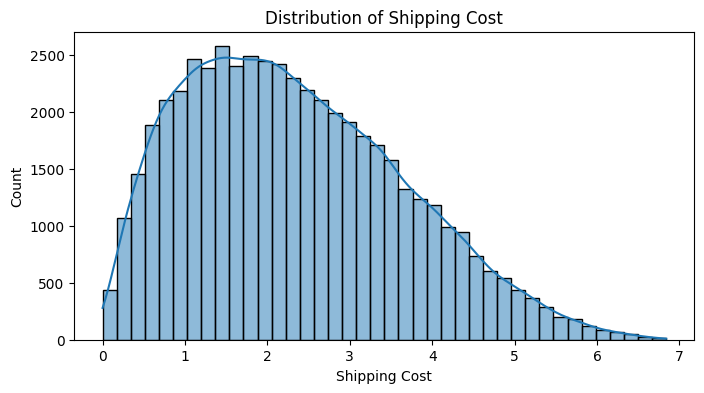

In [43]:
num_cols = ["Sales", "Quantity", "Discount", "Shipping Cost"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.show()

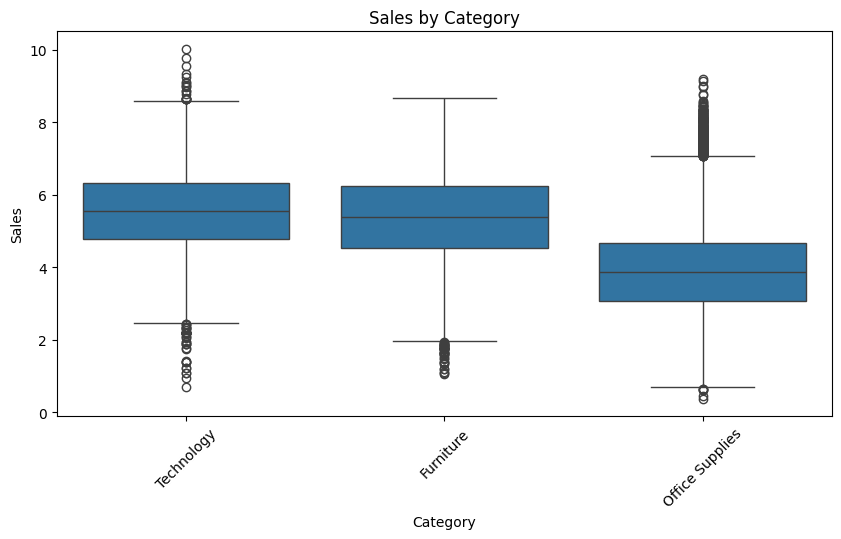

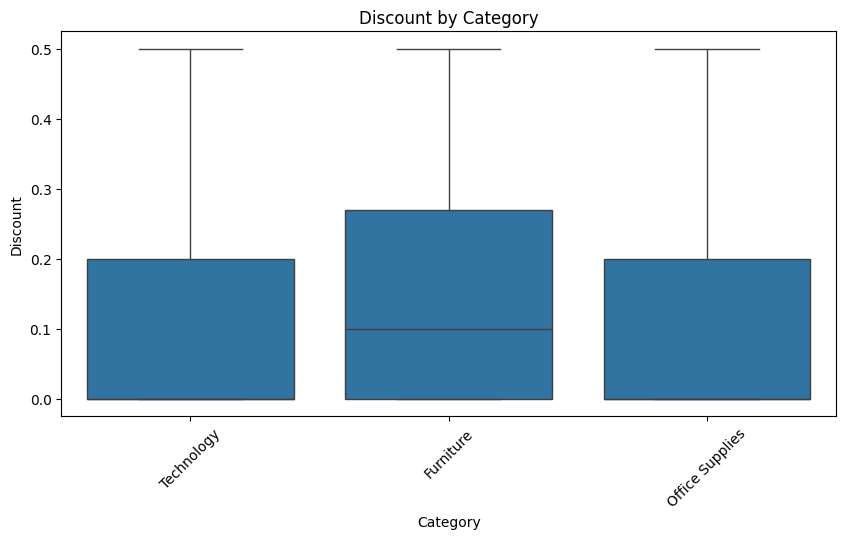

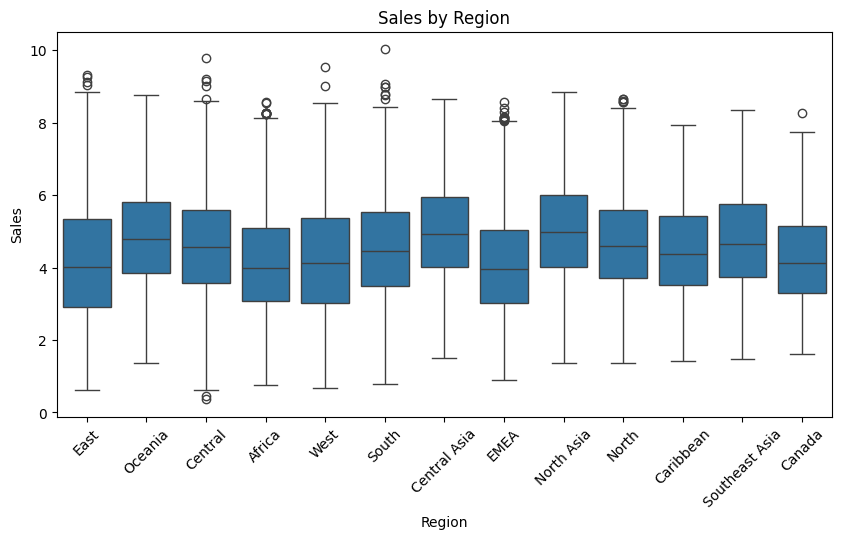

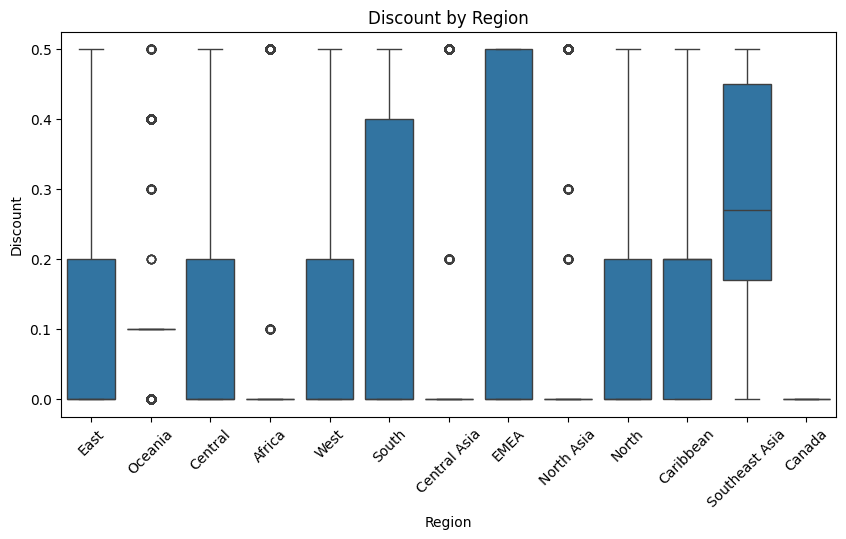

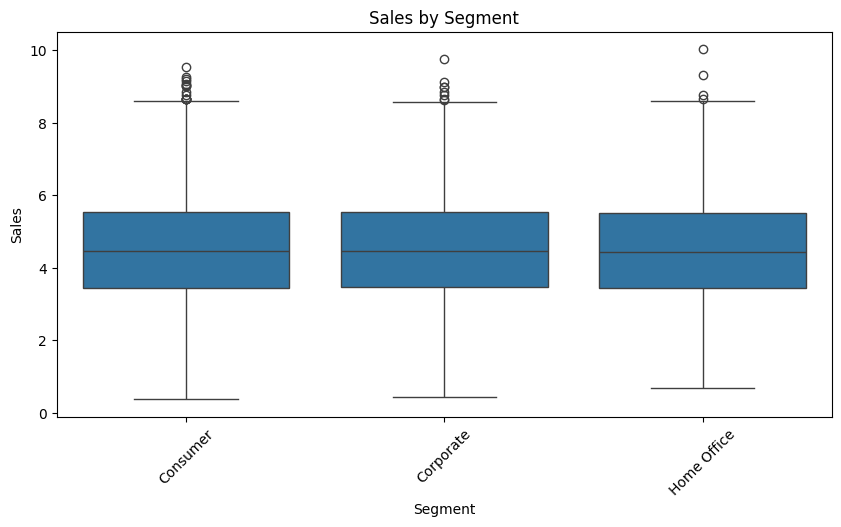

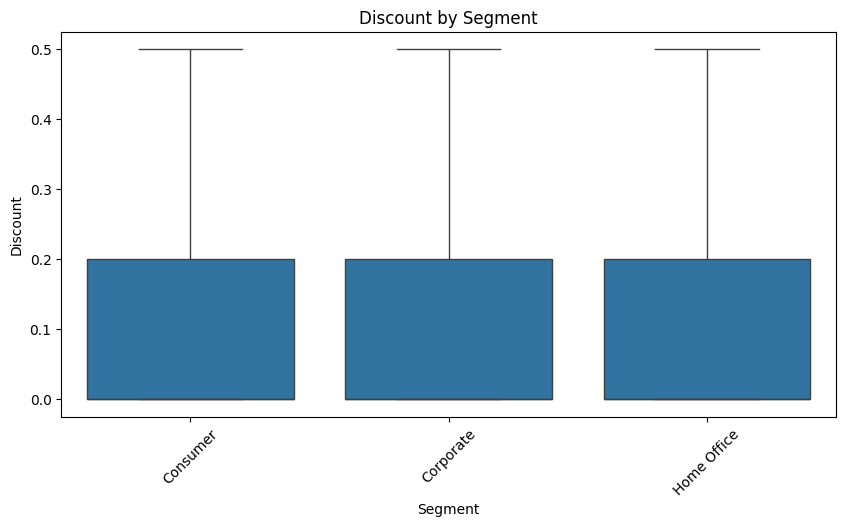

In [44]:
features = ["Sales", "Discount"]
groups = ["Category", "Region", "Segment"]

for g in groups:
    for f in features:
        plt.figure(figsize=(10,5))
        sns.boxplot(x=g, y=f, data=df)
        plt.title(f"{f} by {g}")
        plt.xticks(rotation=45)
        plt.show()

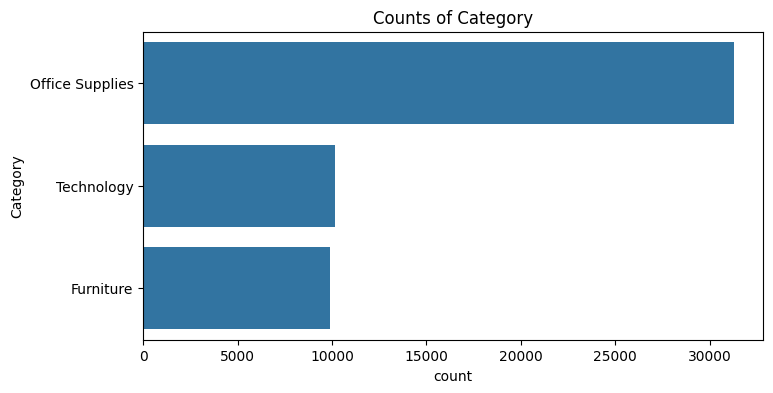

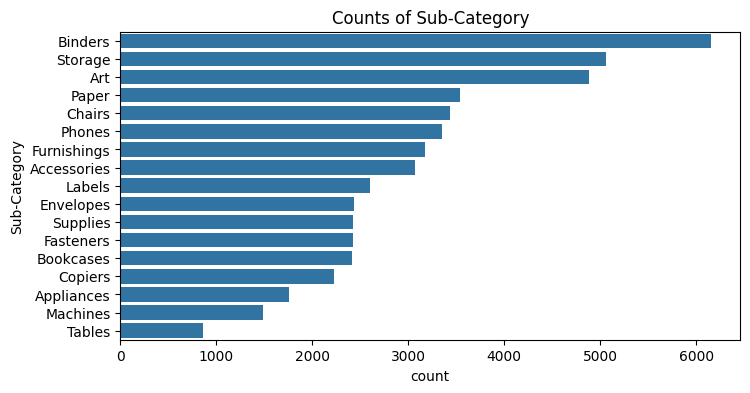

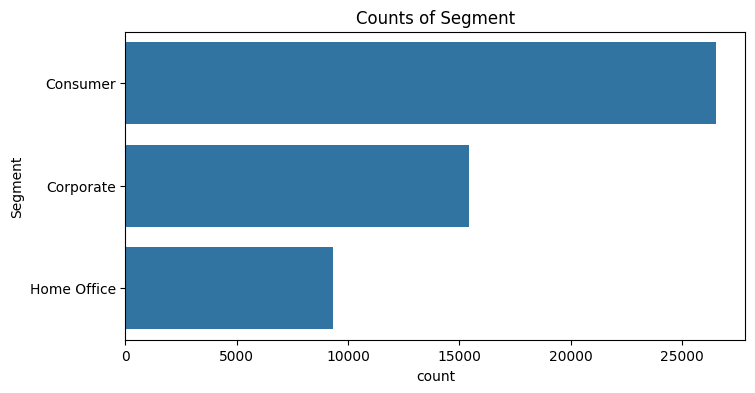

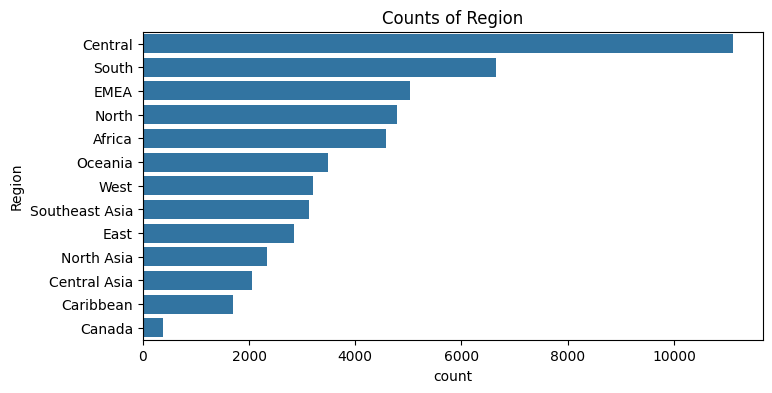

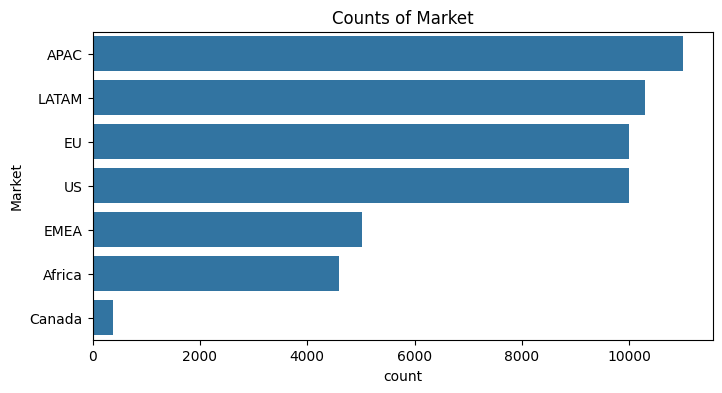

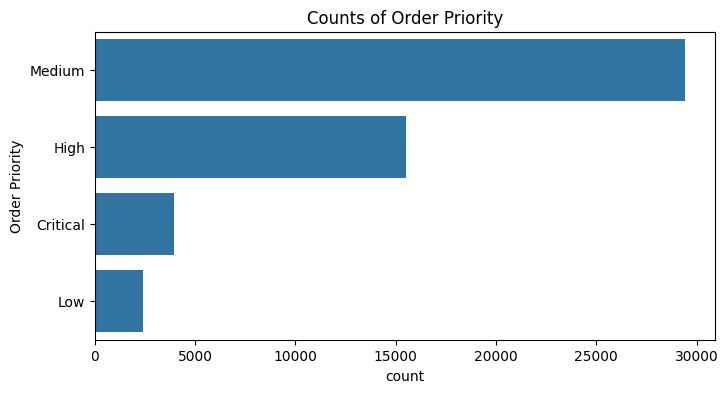

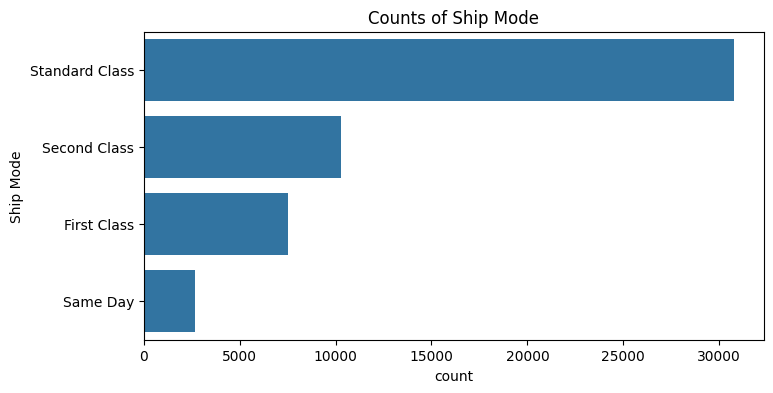

In [45]:
cat_cols = ["Category", "Sub-Category", "Segment", "Region", "Market", "Order Priority", "Ship Mode"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Counts of {col}")
    plt.show()


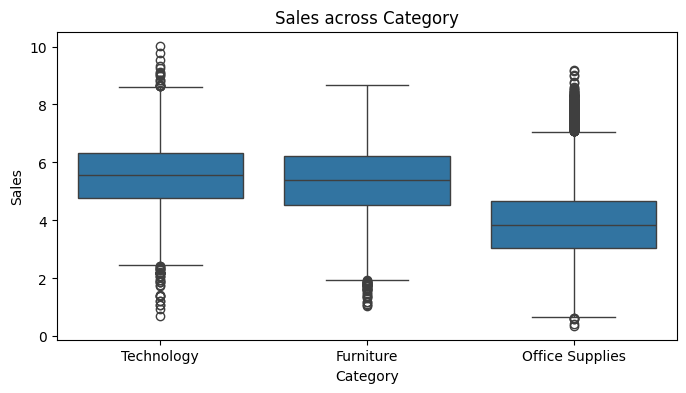

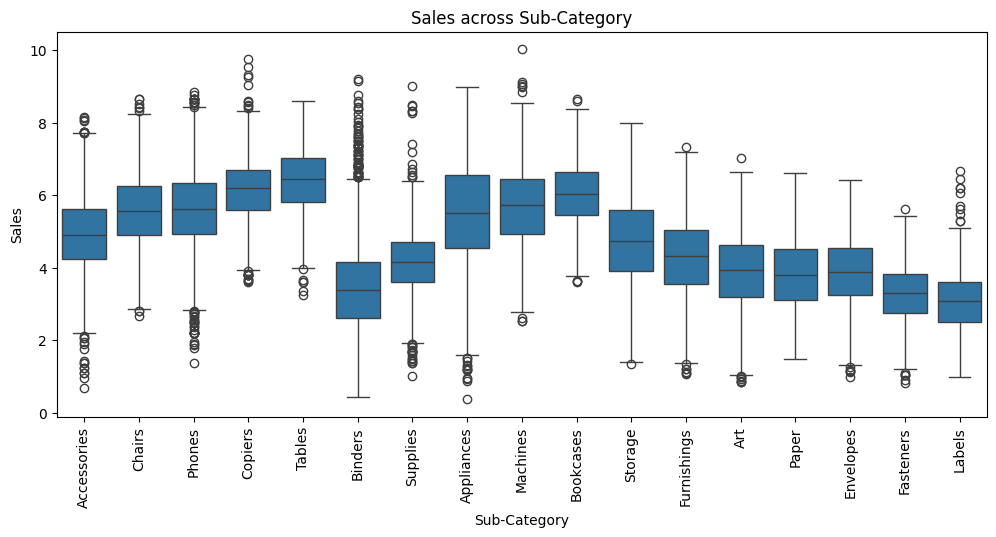

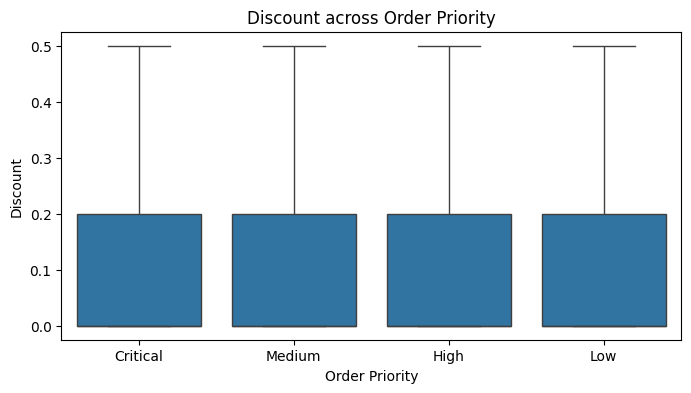

In [46]:

plt.figure(figsize=(8,4))
sns.boxplot(x="Category", y="Sales", data=df)
plt.title("Sales across Category")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x="Sub-Category", y="Sales", data=df)
plt.xticks(rotation=90)
plt.title("Sales across Sub-Category")
plt.show()


plt.figure(figsize=(8,4))
sns.boxplot(x="Order Priority", y="Discount", data=df)
plt.title("Discount across Order Priority")
plt.show()


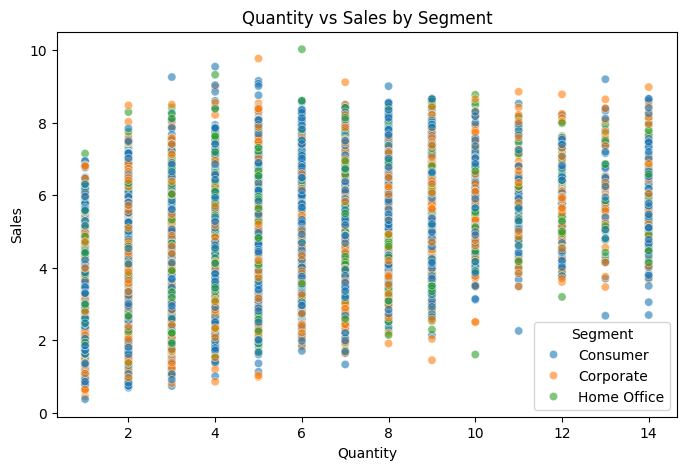

In [47]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Quantity", y="Sales", hue="Segment", data=df, alpha=0.6)
plt.title("Quantity vs Sales by Segment")
plt.show()


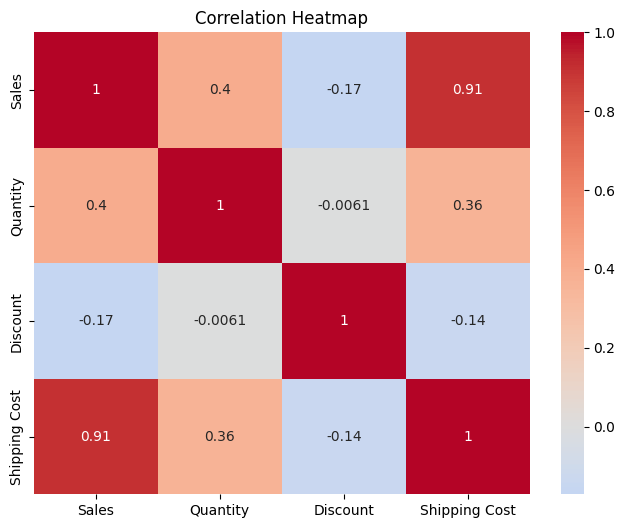

In [48]:
corr_cols = ["Sales", "Quantity", "Discount", "Shipping Cost"]
corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


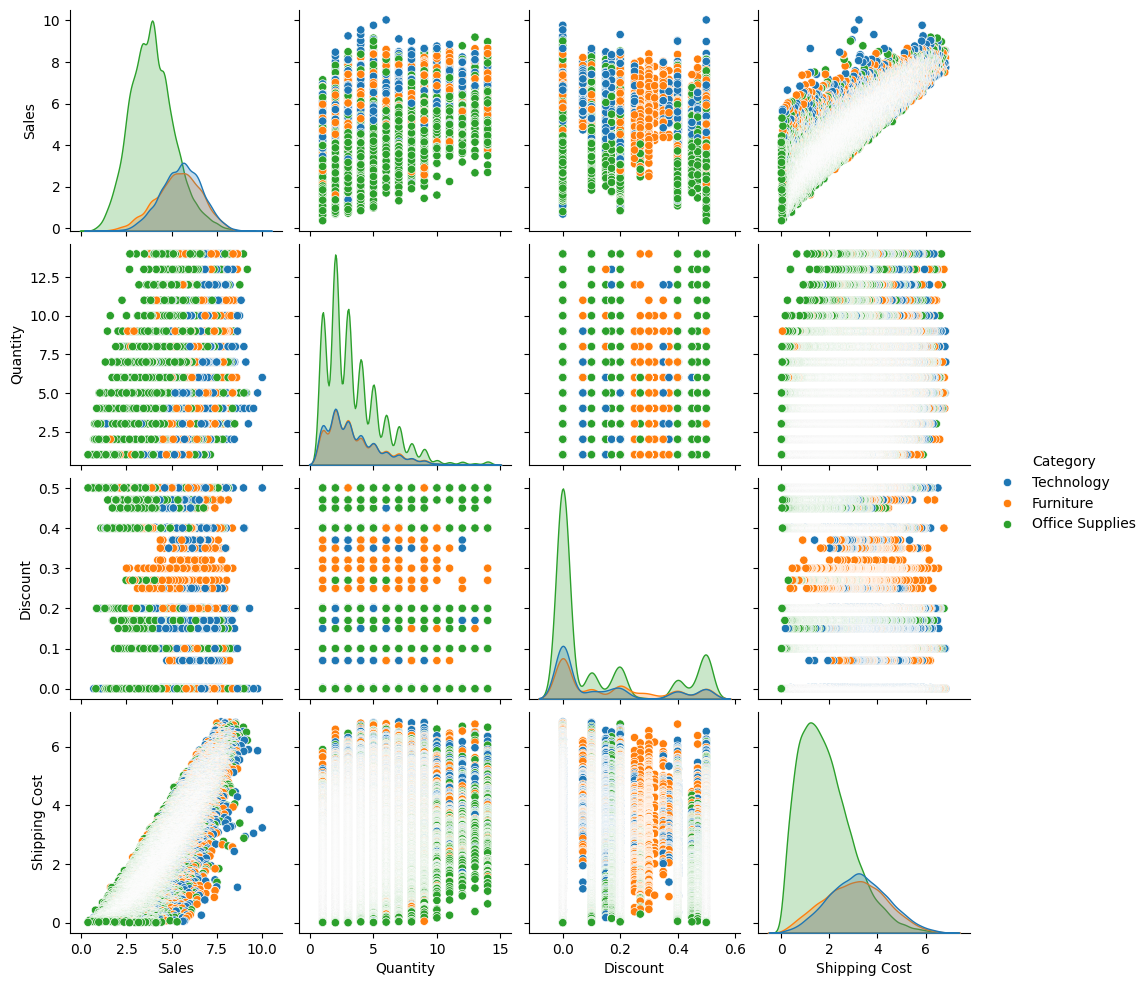

In [49]:
sns.pairplot(df[["Sales", "Quantity", "Discount", "Shipping Cost", "Category"]],
             hue="Category", diag_kind="kde")
plt.show()

## Split Data


In [50]:
target_cols = ['Sales', 'Shipping Cost', 'Discount']
y = test[target_cols]
X = test.drop(['Order Date'] + target_cols, axis=1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (51290, 84)
Shape of y: (51290, 3)


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (41032, 84)
Shape of X_test: (10258, 84)
Shape of y_train: (41032, 3)
Shape of y_test: (10258, 3)


## Train XGBoost Model

In [52]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

xgb = XGBRegressor(random_state=42)
multi_output_xgb = MultiOutputRegressor(xgb)

multi_output_xgb.fit(X_train, y_train)
print("Multi-output XGBoost model trained successfully.")

Multi-output XGBoost model trained successfully.


## Evaluate Model Performance


In [53]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = multi_output_xgb.predict(X_test)

for i, col in enumerate(target_cols):
    print(f"\nMetrics for {col}:")
    r2 = r2_score(y_test[col], y_pred[:, i])
    mae = mean_absolute_error(y_test[col], y_pred[:, i])
    mse = mean_squared_error(y_test[col], y_pred[:, i])

    print(f"  R-squared: {r2:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")


Metrics for Sales:
  R-squared: 0.9459
  MAE: 0.2508
  MSE: 0.1116

Metrics for Shipping Cost:
  R-squared: 0.8548
  MAE: 0.3715
  MSE: 0.2535

Metrics for Discount:
  R-squared: 0.9405
  MAE: 0.0237
  MSE: 0.0020


deployment

In [55]:
import joblib
import pickle

# -----------------------------
# 1) Save trained ML model
# -----------------------------
with open('model.pkl', 'wb') as file:
    pickle.dump(multi_output_xgb, file)

# -----------------------------
# 2) Save OneHotEncoder
# -----------------------------
joblib.dump(ohe, "ohe_encoder.pkl")

# -----------------------------
# 3) Save BinaryEncoder
# -----------------------------
joblib.dump(bin, "binary_encoder.pkl")

# -----------------------------
# 4) Save Manual Priority Mapping
# -----------------------------
priority_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Critical": 3
}
joblib.dump(priority_map, "priority_map.pkl")

print("Model and encoders saved successfully!")


Model and encoders saved successfully!


In [56]:
print("=== Columns used to train X ===")
print(X.columns)
print("Number of features:", X.shape[1])


=== Columns used to train X ===
Index(['City_0', 'City_1', 'City_2', 'City_3', 'City_4', 'City_5', 'City_6',
       'City_7', 'City_8', 'State_0', 'State_1', 'State_2', 'State_3',
       'State_4', 'State_5', 'State_6', 'State_7', 'State_8', 'Country_0',
       'Country_1', 'Country_2', 'Country_3', 'Country_4', 'Country_5',
       'Country_6', 'Product Name_0', 'Product Name_1', 'Product Name_2',
       'Product Name_3', 'Product Name_4', 'Product Name_5', 'Product Name_6',
       'Product Name_7', 'Product Name_8', 'Product Name_9', 'Product Name_10',
       'Product Name_11', 'Quantity', 'year', 'month', 'day', 'day_of_week',
       'is_weekend', 'lb_Order Priority', 'Segment_Consumer',
       'Segment_Corporate', 'Segment_Home Office', 'Ship Mode_First Class',
       'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Region_Africa', 'Region_Canada',
       'Region_Caribbean', 'Region_Central', 'Region_Central Asia',
       'Region_EMEA', 'Region_Eas

In [57]:
bin_cols = bin_encode.filter(regex="City|State|Country|Product Name|_0$|_1$").shape[1]
print("BinaryEncoder columns:", bin_cols)


BinaryEncoder columns: 37


In [58]:
print("OneHotEncoder columns:", len(encoded_feature_names))


OneHotEncoder columns: 40


In [60]:
print("Total features used in X:", bin_cols + len(encoded_feature_names) + 7)

Total features used in X: 84


In [61]:
print(X.columns)
print(X.shape)
bin_encode.shape
df_encode.shape
priority_map
multi_output_xgb.estimators_[0].n_features_in_

Index(['City_0', 'City_1', 'City_2', 'City_3', 'City_4', 'City_5', 'City_6',
       'City_7', 'City_8', 'State_0', 'State_1', 'State_2', 'State_3',
       'State_4', 'State_5', 'State_6', 'State_7', 'State_8', 'Country_0',
       'Country_1', 'Country_2', 'Country_3', 'Country_4', 'Country_5',
       'Country_6', 'Product Name_0', 'Product Name_1', 'Product Name_2',
       'Product Name_3', 'Product Name_4', 'Product Name_5', 'Product Name_6',
       'Product Name_7', 'Product Name_8', 'Product Name_9', 'Product Name_10',
       'Product Name_11', 'Quantity', 'year', 'month', 'day', 'day_of_week',
       'is_weekend', 'lb_Order Priority', 'Segment_Consumer',
       'Segment_Corporate', 'Segment_Home Office', 'Ship Mode_First Class',
       'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Region_Africa', 'Region_Canada',
       'Region_Caribbean', 'Region_Central', 'Region_Central Asia',
       'Region_EMEA', 'Region_East', 'Region_North', 'Region_Nort

84

In [6]:
df['Discount'].max()

0.85